output torch.Size([4, 384])


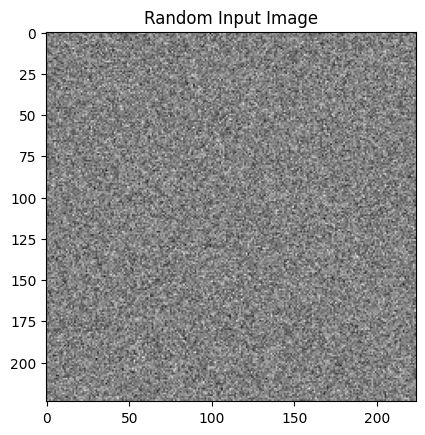

Feature vector for image 0 : tensor([ 0.8959,  0.5290,  1.5476, -0.3747,  0.3723, -1.0048,  0.1730,  1.2706,
        -0.3522,  1.3181]) ...


In [9]:
import torch
import yaml
from multi_channel_vit import get_multi_channel_vit
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load model config
with open("model_config.yaml", "r") as f:
    model_cfg = yaml.safe_load(f)
model_cfg["in_chans"] = 1  # single channel
model = get_multi_channel_vit(**model_cfg)

# Load checkpoint
checkpoint_path = "/scr/vidit/Models/SimCLR_CHAMMI/checkpoint_epoch_100.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Generate random image batch (batch_size=4, 1 channel, 224x224)
batch_size = 4
images = torch.randn(batch_size, 1, 224, 224)

# Forward pass to get features
with torch.no_grad():
    # If model returns a dict, get features from 'features' or similar key
    output = model(images)
    print("output", output["output"].shape)


# Visualize one random image and its feature vector
idx = np.random.randint(0, batch_size)
img = images[idx, 0].numpy()
plt.imshow(img, cmap="gray")
plt.title("Random Input Image")
plt.show()
print("Feature vector for image", idx, ":", features["output"][idx].flatten()[:10], "...")